<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Solar_system_PPN_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

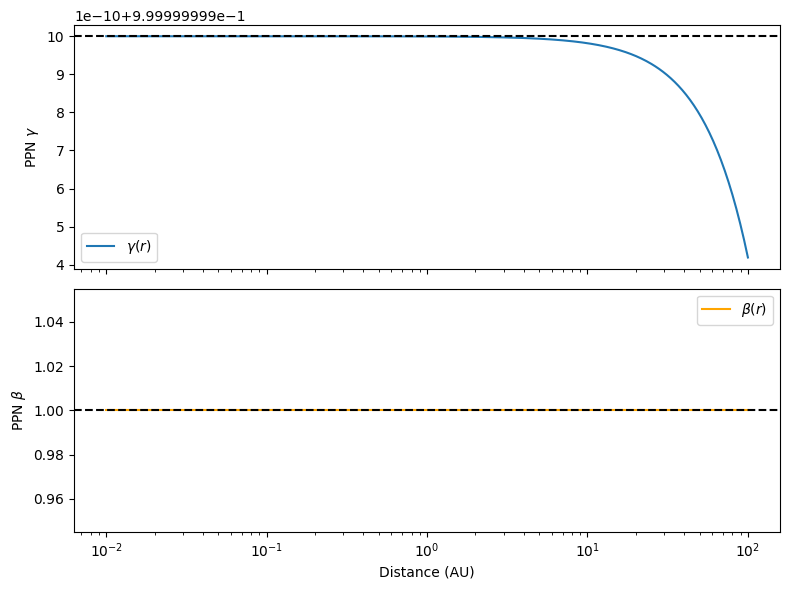

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 1. PHYSICAL CONSTANTS
AU = 1.496e11
PC = 3.0857e16
R_CASSINI = 0.7 * AU
R_LLR = 1.0 * AU

# 2. CLASS DEFINITION
class LogicRelativityPPN:
    def __init__(self, r_v, alpha_fifth):
        self.r_v = r_v
        self.alpha_fifth = alpha_fifth

    def vainshtein_screening_profile(self, r):
        if r == 0: return 0.0
        return 1.0 / (1.0 + (self.r_v / r)**(1.5))

    def calculate_gamma(self, r):
        return 1.0 - (2.0 * self.alpha_fifth * self.vainshtein_screening_profile(r))

    def calculate_beta(self, r):
        return 1.0 + (self.alpha_fifth**2 * (self.vainshtein_screening_profile(r)**2))

# 3. INITIALIZATION
lr_engine = LogicRelativityPPN(r_v=150.0 * PC, alpha_fifth=0.05)

# 4. PLOTTING
radii = np.logspace(-2, 2, 500) * AU
gammas = [lr_engine.calculate_gamma(r) for r in radii]
betas = [lr_engine.calculate_beta(r) for r in radii]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(radii/AU, gammas, label=r'$\gamma(r)$')
ax1.axhline(1, color='k', ls='--')
ax1.set_xscale('log')
ax1.set_ylabel(r'PPN $\gamma$')
ax1.legend()

ax2.plot(radii/AU, betas, color='orange', label=r'$\beta(r)$')
ax2.axhline(1, color='k', ls='--')
ax2.set_xscale('log')
ax2.set_ylabel(r'PPN $\beta$')
ax2.set_xlabel('Distance (AU)')
ax2.legend()

plt.tight_layout()
plt.show()